### IPL 2022 Capstone Project

**The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.**

**These are some of the important columns that we'll focus on for meaningful insights in this project.**

**column names: Variable Type**
* date : string  
* venue : string  
* stage : string  
* team1 : string  
* team2 : string  
* toss_winner : string  
* toss_decision : string  
* first_ings_score : integer  
* second_ings_score : integer  
* match_winner : string  
* won_by : string  
* margin : integer  
* player_of_the_match : string  
* top_scorer : string  
* highscore : integer  
* best_bowling : string  
* best_bowling_fgure : string  
gure : string  


### Loading the Libraries and Dataset

`import pandas as pd`, `numpy`, `seaborn`, and `matplotlib.pyplot` bring in the libraries used throughout this notebook: pandas for handling tabular data, numpy for numerical operations, and seaborn/matplotlib for plotting. `pd.read_csv('IPL.csv')` reads the IPL match data from a CSV file into a pandas DataFrame called `df`, which is the table we'll work with for the rest of the project. `df.head()` shows the first 5 rows of that table so you can quickly see what the columns and values look like.

**Usecase:** Used here to load the raw IPL 2022 match data into memory and take a first look at columns like `team1`, `team2`, `toss_winner`, and `match_winner` before doing any analysis.

In [57]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

df = pd.read_csv( 'data/IPL.csv')

df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### Basic Information

`df.info()` prints a summary of the DataFrame: how many rows and columns it has, the name of each column, how many non-null (filled in) values each column has, and what data type (text, integer, etc.) each column is stored as.

**Usecase:** Used here to quickly check whether any of the 20 IPL columns (like `first_ings_score` or `match_winner`) have missing values or an unexpected data type before doing further analysis.

In [58]:
# Memory usage and data types overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   match_id             74 non-null     int64
 1   date                 74 non-null     str  
 2   venue                74 non-null     str  
 3   team1                74 non-null     str  
 4   team2                74 non-null     str  
 5   stage                74 non-null     str  
 6   toss_winner          74 non-null     str  
 7   toss_decision        74 non-null     str  
 8   first_ings_score     74 non-null     int64
 9   first_ings_wkts      74 non-null     int64
 10  second_ings_score    74 non-null     int64
 11  second_ings_wkts     74 non-null     int64
 12  match_winner         74 non-null     str  
 13  won_by               74 non-null     str  
 14  margin               74 non-null     int64
 15  player_of_the_match  74 non-null     str  
 16  top_scorer           74 non-null     st

Check the size of rows and columns of the dataset

`df.shape` returns a pair of numbers: the number of rows and the number of columns in the DataFrame. `df.shape[0]` is the row count and `df.shape[1]` is the column count, and here they're plugged into an f-string to print a readable sentence.

**Usecase:** Used here to confirm the dataset has 74 matches (rows) and 20 pieces of information (columns) about each match.

In [59]:
print(f"your rows are {df.shape[0]} and your columns are {df.shape[1]}")

your rows are 74 and your columns are 20


Now let's see how many columns have null values in total.

`df.isnull()` checks every cell in the DataFrame and marks it `True` if it's empty/missing and `False` if it has a value. Chaining `.sum()` on top adds up the `True`s for each column, so you get a count of missing values per column.

**Usecase:** Used here to double check that none of the IPL columns, like `player_of_the_match` or `best_bowling_figure`, have missing data that would need to be cleaned up.

In [60]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

**Now, Here comes some Basic Questions**

1. Which team won the most matches?

Typing a variable name by itself on the last line of a cell tells Jupyter to display its value, similar to `print()` but formatted a bit nicer for things like pandas Series.

**Usecase:** Used here to display `match_wins`, the count of how many matches each team won, so we can look at the numbers before turning them into a chart.

`df['match_winner'].value_counts()` counts how many times each team name appears in the `match_winner` column, effectively giving how many matches each team won, and stores the result in `match_wins`. `sns.barplot(y=..., x=..., palette='viridis')` then draws a horizontal bar chart from that, one bar per team, with the bar length showing the win count. `plt.title(...)` adds a title on top of the chart.

**Usecase:** Used here to visually compare which IPL teams won the most matches in the 2022 season, based on the `match_winner` column.

Text(0.5, 1.0, 'Most match win by team ')

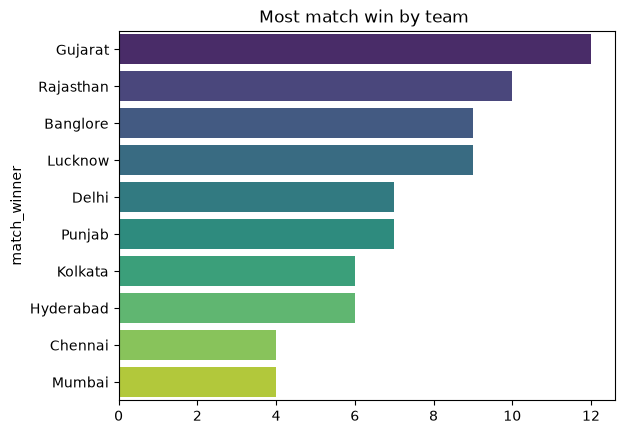

In [61]:
match_wins = df['match_winner'].value_counts()
sns.barplot(y = match_wins.index,x = match_wins.values,palette='viridis')
plt.title("Most match win by team ")

In [62]:
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

2. Toss Decision Trends

`sns.countplot(x=df['toss_decision'], palette='rainbow')` automatically counts how many times each unique value appears in the `toss_decision` column (like 'Field' or 'Bat') and draws a bar for each one, without you having to count them yourself first.

**Usecase:** Used here to see whether teams that won the toss preferred to bat first or field first across the season.

Text(0.5, 1.0, 'Toss Decision Trends ')

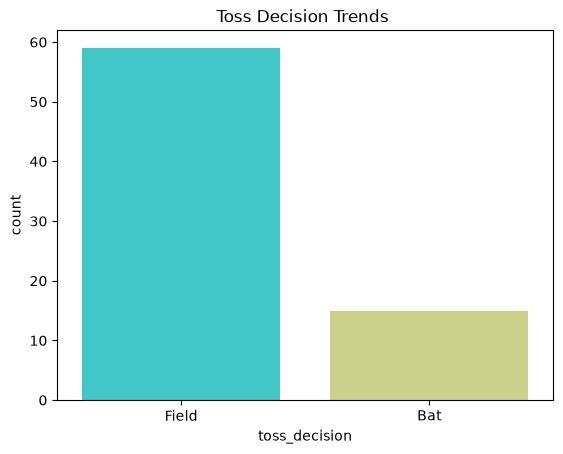

In [63]:
sns.countplot(x = df['toss_decision'],palette='rainbow')
plt.title("Toss Decision Trends ")

3. Toss Winner vs Match Winner

`df[df['toss_winner'] == df['match_winner']]` filters the DataFrame down to only the rows where the team that won the toss was also the team that won the match, and `['match_id'].count()` counts how many such rows there are. Dividing that count by the total number of matches (`df.shape[0]`) and multiplying by 100 turns it into a percentage, and `.round(2)` rounds it to 2 decimal places.

**Usecase:** Used here to check how often winning the toss (`toss_winner`) actually translated into winning the match (`match_winner`).

In [64]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count * 100)/df.shape[0]
round(percentage, 2)

np.float64(48.65)

4. How do teams win? (Runs vs Wickets)

`sns.countplot(x=df['won_by'])` counts how many matches were won by each category in the `won_by` column (like 'Runs' or 'Wickets') and draws a bar for each.

**Usecase:** Used here to see whether IPL teams tend to win by defending a total (runs) or by chasing it down (wickets) more often.

Text(0.5, 1.0, 'Won by')

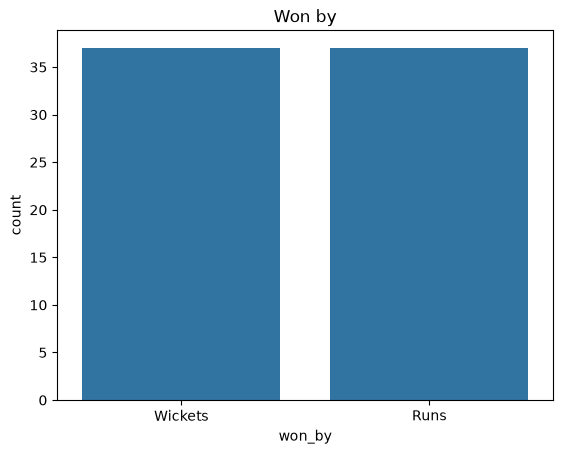

In [65]:
sns.countplot(x = df['won_by'])
plt.title("Won by")

###  Key Player Performances

1 Most "Player of the Match" Awards

`df['player_of_the_match'].value_counts()` counts how many times each player's name appears in the `player_of_the_match` column, which tells you how many times each player was named man of the match. `.head(10)` then keeps only the top 10 players with the most awards.

**Usecase:** Used here to find out which players were most consistently outstanding across the IPL 2022 matches, based on `player_of_the_match` awards.

In [80]:
count = df['player_of_the_match'].value_counts().head(10)
count


player_of_the_match
Kuldeep Yadav        4
Jos Buttler          3
Umesh Yadav          2
Wanindu Hasaranga    2
Avesh Khan           2
Dinesh Karthik       2
Quinton de Kock      2
Shubman Gill         2
Yuzvendra Chahal     2
Hardik Pandya        2
Name: count, dtype: int64

`sns.barplot(x=count.values, y=count.index, palette='mako')` takes the top-10 player counts calculated in the previous cell and draws them as a horizontal bar chart, with player names on the y-axis and their award counts as the bar length.

**Usecase:** Used here to visually rank the top 10 "Player of the Match" winners so it's easier to compare them at a glance than reading a table of numbers.

Text(0.5, 1.0, 'Top 10 players with man of the match')

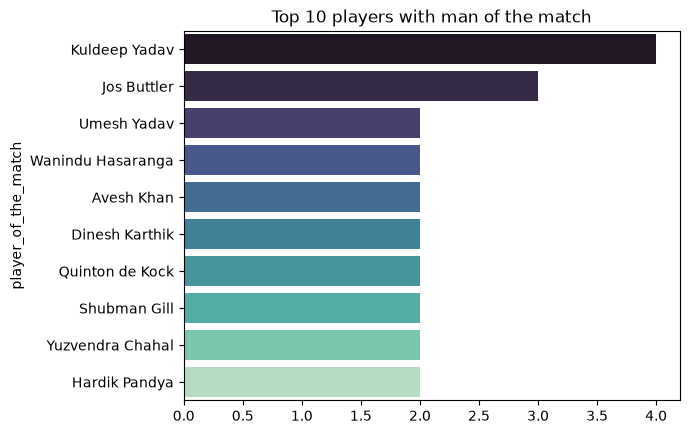

In [79]:
sns.barplot(x = count.values , y = count.index,palette='mako')
plt.title("Top 10 players with man of the match")

2 Top Scorers

`df.head()` shows the first 5 rows of the DataFrame again, as a quick reminder of what the columns and values look like.

**Usecase:** Used here to re-check the available columns, like `top_scorer` and `highscore`, before digging into who scored the most runs.

In [68]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


`df.groupby('top_scorer')['highscore'].sum()` groups all rows by the player's name in `top_scorer` and adds up their `highscore` values across matches, giving a total runs figure per player. `.sort_values(ascending=False)` puts the players with the highest totals first, and `.head(2)` keeps just the top 2.

**Usecase:** Used here to find out which two players racked up the most runs overall as the top scorer of their matches across the season.

In [81]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

`.plot(kind='barh')` is a shortcut built into pandas that draws a horizontal bar chart directly from a Series, without needing to call seaborn or matplotlib separately.

**Usecase:** Used here to turn the top-2 run scorers calculated in the previous cell into a simple bar chart for a quick visual comparison.

<Axes: ylabel='top_scorer'>

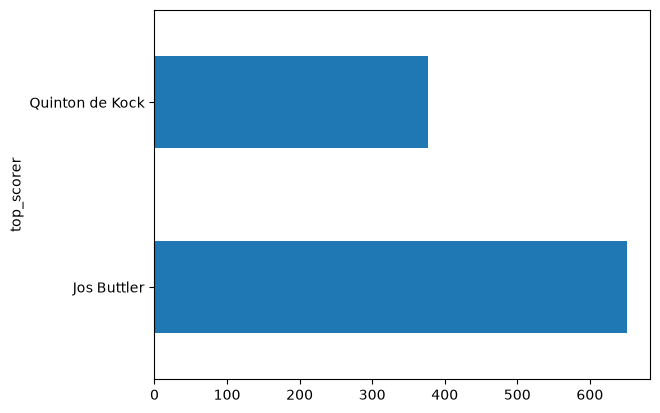

In [82]:
high.plot(kind = 'barh')

10 Best Bowling Figures

`df.head()` again prints the first 5 rows of the DataFrame so you can see the current state of the columns.

**Usecase:** Used here to look at the `best_bowling_figure` column format (like '3--20') before extracting the wicket count out of it.

In [71]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


`df['best_bowling_figure'].apply(lambda x: x.split('--')[0])` splits each text value like '3--20' on the '--' and keeps the first part, which is the number of wickets, then `.astype(int)` converts that text into an actual number and stores it in a new column called `highest_wickets`. `df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)` then groups by bowler name, adds up their wickets, sorts from highest to lowest, and keeps the top 10, and `.plot(kind='barh')` draws that as a horizontal bar chart.

**Usecase:** Used here to figure out which bowlers took the most wickets in their best spells across the season, by pulling the wicket count out of the combined `best_bowling_figure` text.

<Axes: ylabel='best_bowling'>

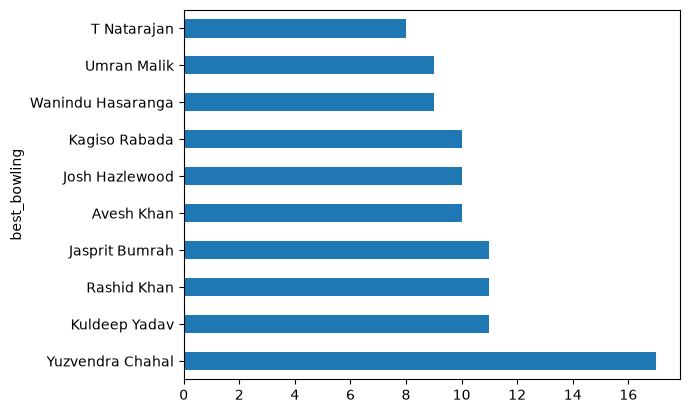

In [72]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x :x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)
top_bowlers.plot(kind = 'barh')

###  Venue Analysis

Most Matches Played by Venue

`df['venue'].value_counts()` counts how many matches were played at each stadium listed in the `venue` column.

**Usecase:** Used here to see which grounds hosted the most IPL 2022 matches.

In [83]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

`sns.barplot(y=venue_count.index, x=venue_count.values, palette='rainbow')` draws the venue match counts from the previous cell as a horizontal bar chart, one bar per stadium.

**Usecase:** Used here to visually compare how many matches each venue hosted instead of just reading the numbers.

<Axes: ylabel='venue'>

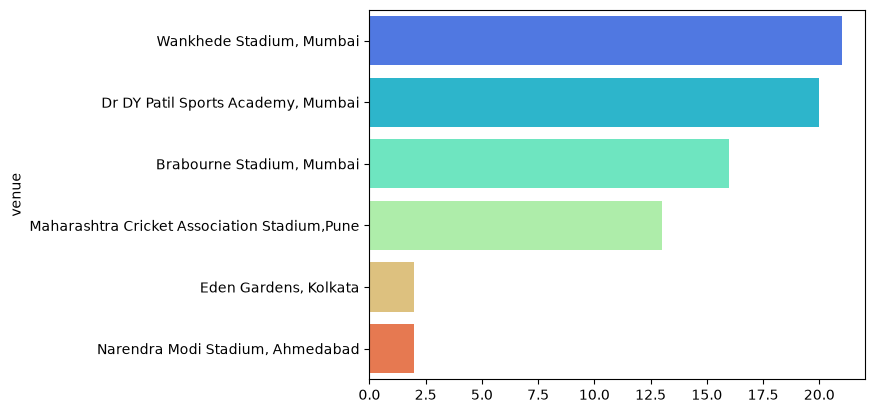

In [74]:
sns.barplot(y = venue_count.index,x = venue_count.values,palette='rainbow')

### Custom Questions & Insights
Q1: Who won the highest margin by runs?

`df[df['won_by'] == 'Runs']` filters the data down to only matches that were won by a run margin (as opposed to wickets). `.sort_values(by='margin', ascending=False)` then sorts those matches from the biggest winning margin to the smallest, and `.head(1)` keeps just the top one. Adding `[['match_winner', 'margin']]` at the end picks out only those two columns to display.

**Usecase:** Used here to find which team won by the largest run margin during the season, using the `won_by` and `margin` columns.

In [75]:
df[df['won_by'] == 'Runs'].sort_values(by = 'margin',ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Q2: Which player had the highest individual score?

`df['highscore'] == df['highscore'].max()` builds a filter that's `True` only for the row where `highscore` has the biggest value in the whole column, and using that inside `df[...]` returns just that row. `[['top_scorer', 'highscore']]` then narrows the result down to just those two columns.

**Usecase:** Used here to find out who scored the highest individual score in a single match, using the `highscore` and `top_scorer` columns.

In [76]:
df[df['highscore'] == df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figures?

`df.head()` shows the first 5 rows again as a reminder of the data, including the newly added `highest_wickets` column.

**Usecase:** Used here to check the columns available, such as `best_bowling` and `best_bowling_figure`, before finding the best bowling performance of the season.

In [77]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3


`df['highest_wickets'] == df['highest_wickets'].max()` builds a filter that's `True` only for the row(s) where `highest_wickets` equals the highest value in that column, and `df[...]` uses it to pull out just those rows. `[['best_bowling', 'best_bowling_figure']]` then keeps only the bowler's name and their full figures for display.

**Usecase:** Used here to identify which bowler(s) had the best bowling figures (most wickets in a single spell) of the IPL 2022 season.

In [78]:
df[df['highest_wickets'] == df['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
